<a href="https://colab.research.google.com/github/tciodaro/GRLCDDR1C1-N2-L2-PB/blob/main/segmentacao.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from sklearn import datasets
import pandas as pd
import matplotlib.pyplot as plt


categories = [
  # 'alt.atheism',
  # 'comp.graphics',
  'comp.os.ms-windows.misc',
  'comp.sys.ibm.pc.hardware',
  # 'comp.sys.mac.hardware',
  # 'comp.windows.x',
  # 'misc.forsale',
  # 'rec.autos',
  # 'rec.motorcycles',
  # 'rec.sport.baseball',
  # 'rec.sport.hockey',
  # 'sci.crypt',
  # 'sci.electronics',
  # 'sci.med',
  # 'sci.space',
  # 'soc.religion.christian',
  # 'talk.politics.guns',
  # 'talk.politics.mideast',
  # 'talk.politics.misc',
  # 'talk.religion.misc'
]



# Carga dos Dados de Texto

In [ ]:

trn = datasets.fetch_20newsgroups(subset='train', categories=categories)

df = pd.DataFrame(trn.data, columns=['text'])
df['target'] = trn.target
df['target_names'] = df.target.apply(lambda x: trn.target_names[x])

df.head()

from sklearn.model_selection import train_test_split

# Split data into development and validation sets (80/20 ratio)
X_train, X_test, y_train, y_test = train_test_split(
    df[['text']],
    df['target'],
    test_size=0.2,
    stratify=df['target'],
    random_state=42
)

print("Data splitting complete.")
print(f"X_train shape: {X_train.shape}")
print(f"X_val shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_val shape: {y_test.shape}")


Data splitting complete.
X_train shape: (944, 1)
X_val shape: (237, 1)
y_train shape: (944,)
y_val shape: (237,)


In [ ]:

from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import PCA
from sklearn import cluster


n_clusters=5

# Preprocessor

# TF-IDF
vectorizer = TfidfVectorizer(
    token_pattern=r"(?u)\b[A-Za-z]+\b",
    max_features=500,
    stop_words='english'
)

# PCA
pca_model = PCA(
    n_components=200
)

# Clusterizador
clf = cluster.KMeans(
    n_clusters = n_clusters
)


# Create a Pipeline that combines the preprocessor and the kNN classifier
# This step needs to be re-executed after the preprocessor was updated.
classifier = Pipeline(steps=[('tf-idf', vectorizer),
                        ('pca', pca_model),
                        ('classifier', clf)])
classifier.fit(X_train['text'])

cluster_labels = classifier.predict(X_train['text'])

In [ ]:
from sklearn import metrics
import numpy as np

max_clusters = 8
n_iter = 10

cluster_avg_silhouette = []
cluster_std_silhouette = []
cluster_list = list(range(2, max_clusters+1))
for n in cluster_list:
  score_list = []
  for it in range(n_iter):
    clf = cluster.KMeans(n_clusters = n, n_init=1)
    classifier = Pipeline(
        steps=[('tf-idf', vectorizer),
               ('pca', pca_model),
               ('classifier', clf)]
    )

    classifier.fit(X_train['text'])
    cluster_labels = classifier.predict(X_train['text'])
    # Silhueta
    tfidf_vec = classifier.steps[0][1].transform(X_train['text'])
    pca_proj =  classifier.steps[1][1].transform(tfidf_vec)
    silhouette_avg = metrics.silhouette_score(pca_proj, cluster_labels)
    score_list.append(silhouette_avg)

  cluster_avg_silhouette.append(np.mean(score_list))
  cluster_std_silhouette.append(np.std(score_list))




In [ ]:
plt.errorbar?

Object `plt.errorbar` not found.


<ErrorbarContainer object of 3 artists>

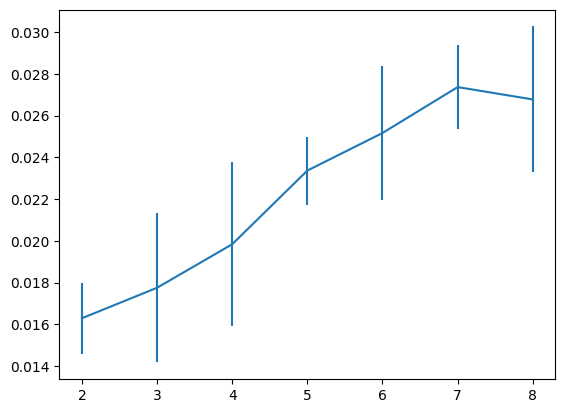

In [ ]:
plt.errorbar(cluster_list, cluster_avg_silhouette, cluster_std_silhouette, 0)




In [ ]:
# from sklearn import metrics

tfidf_vec = classifier.steps[0][1].transform(X_train['text'])
pca_proj =  classifier.steps[1][1].transform(tfidf_vec)
silhouette_scores = metrics.silhouette_samples(pca_proj, cluster_labels)
silhouette_avg = metrics.silhouette_score(pca_proj, cluster_labels)
# # cluster_labels
# # metrics.silhouette_score(X_train, cluster_labels)
# import matplotlib.pyplot as plt

# plt.scatter(pca_proj[:, 0], pca_proj[:, 1], c=cluster_labels)

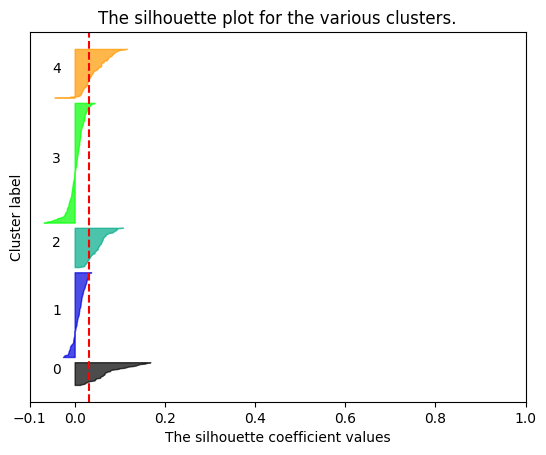

In [ ]:
from __future__ import print_function

from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_samples, silhouette_score

import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

plt.figure()

ax = plt.gca()

y_lower = 10
for i in range(n_clusters):
    # Aggregate the silhouette scores for samples belonging to
    # cluster i, and sort them
    ith_cluster_silhouette_values = \
        silhouette_scores[cluster_labels == i]

    ith_cluster_silhouette_values.sort()

    size_cluster_i = ith_cluster_silhouette_values.shape[0]
    y_upper = y_lower + size_cluster_i

    color = cm.nipy_spectral(float(i) / n_clusters)
    ax.fill_betweenx(np.arange(y_lower, y_upper),
                      0, ith_cluster_silhouette_values,
                      facecolor=color, edgecolor=color, alpha=0.7)

    # Label the silhouette plots with their cluster numbers at the middle
    ax.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))

    # Compute the new y_lower for next plot
    y_lower = y_upper + 10  # 10 for the 0 samples

ax.set_title("The silhouette plot for the various clusters.")
ax.set_xlabel("The silhouette coefficient values")
ax.set_ylabel("Cluster label")

# The vertical line for average silhouette score of all the values
ax.axvline(x=silhouette_avg, color="red", linestyle="--")

ax.set_yticks([])  # Clear the yaxis labels / ticks
ax.set_xticks([-0.1, 0, 0.2, 0.4, 0.6, 0.8, 1])

# 2nd Plot showing the actual clusters formed
colors = cm.nipy_spectral(cluster_labels.astype(float) / n_clusters)

plt.show()

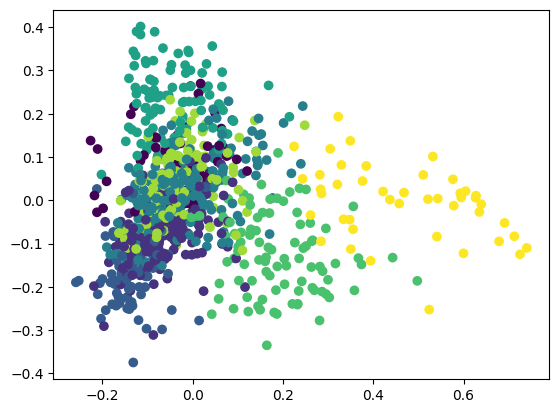

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(pca_proj[:, 0], pca_proj[:, 1], c=cluster_labels)

# Carga dos Dados de Vinho

In [ ]:

import pandas as pd

from google.colab import drive
drive.mount('/content/drive')

fname = 'drive/MyDrive/Curso Projeto de Bloco: Inteligência Artificial e Machine Learning (GRLCDDR1C1-N2-L2)/dataset_vinhos.csv'

target_col = 'target'
target_col_label='target_label'

cat_cols = ['type']

import pandas as pd
from sklearn.model_selection import train_test_split


wine = pd.read_csv(fname, sep=';')

wine['type'] = wine['type'].map({
    'white':0,
    'red': 1,
})

wine = wine[wine['type'] == 1].drop(columns='type').copy()

# Re-defining these variables as their original defining cell was not executed
target_col = 'target'
target_col_label='target_label'

# Separate features (X) and target (y)
y = wine[target_col]
X = wine.drop(columns=[target_col, target_col_label])

# Split data into development and validation sets (80/20 ratio)
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

print("Data splitting complete.")
print(f"X_train shape: {X_train.shape}")
print(f"X_val shape: {X_val.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_val shape: {y_val.shape}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Data splitting complete.
X_train shape: (1087, 11)
X_val shape: (272, 11)
y_train shape: (1087,)
y_val shape: (272,)


In [ ]:

from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import PCA
from sklearn import cluster
from sklearn import preprocessing


n_clusters=5

# Preprocessor

# Scaler
scaler = preprocessing.StandardScaler()

# Clusterizador
clf = cluster.KMeans(
    n_clusters = n_clusters
)


# Create a Pipeline that combines the preprocessor and the kNN classifier
# This step needs to be re-executed after the preprocessor was updated.
classifier = Pipeline(steps=[('scaler', scaler),
                        ('classifier', clf)])
classifier.fit(X_train)
cluster_labels = classifier.predict(X_train)

In [ ]:
max_clusters = 8
n_iter = 10

cluster_avg_silhouette = []
cluster_std_silhouette = []
cluster_list = list(range(2, max_clusters+1))
for n in cluster_list:
  score_list = []
  for it in range(n_iter):
    clf = cluster.KMeans(n_clusters = n, n_init=1)
    classifier = Pipeline(steps=[('scaler', scaler),
                            ('classifier', clf)])

    classifier.fit(X_train)
    cluster_labels = classifier.predict(X_train)
    # Silhueta
    scaled = classifier.steps[0][1].transform(X_train)
    silhouette_avg = metrics.silhouette_score(scaled, cluster_labels)
    score_list.append(silhouette_avg)

  cluster_avg_silhouette.append(np.mean(score_list))
  cluster_std_silhouette.append(np.std(score_list))




<ErrorbarContainer object of 3 artists>

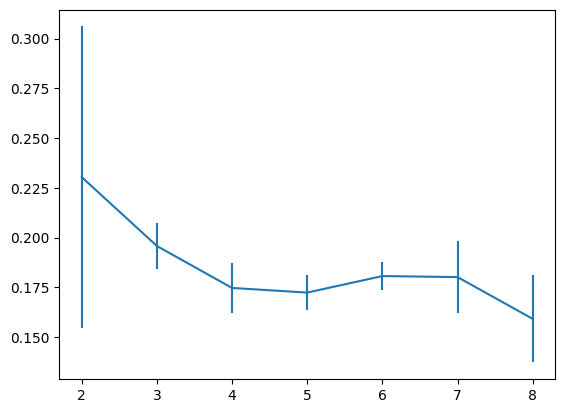

In [ ]:
plt.errorbar(cluster_list, cluster_avg_silhouette, cluster_std_silhouette, 0)



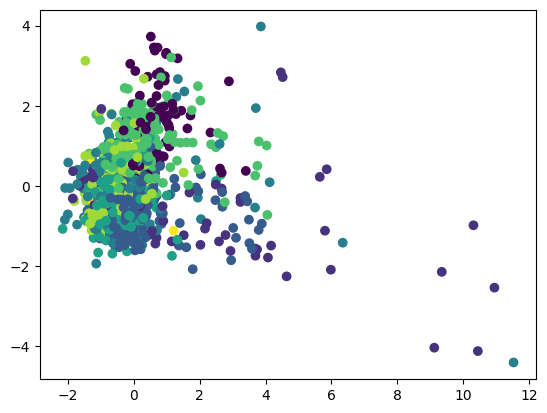

In [ ]:

pca_proj = PCA(n_components=10).fit_transform(X_train)

plt.scatter(pca_proj[:, 3], pca_proj[:, 4], c=cluster_labels)


In [ ]:
clf.cluster_centers_.shape

(8, 11)

In [ ]:
row[1]

(1062,
 fixed acidity              7.400000
 volatile acidity           0.740000
 citric acid                0.070000
 residual sugar             1.700000
 chlorides                  0.086000
 free sulfur dioxide       15.000000
 total sulfur dioxide      48.000000
 density                    0.995020
 pH                         3.120000
 sulphates                  0.480000
 alcohol                   10.000000
 cluster_distance        3520.772203
 Name: 1062, dtype: float64)

In [ ]:
ds = []
cs = []
for row in X_train.iterrows():
  smaller_d = 1e9
  smaller_c = -1
  for c, vc in enumerate(clf.cluster_centers_):
    v = (vc - row[1])
    d = np.sqrt(np.sum(v*v))
    if smaller_d > d:
      smaller_d = d
      smaller_c = c
  ds.append(smaller_d)
  cs.append(smaller_c)


In [ ]:
trn = X_train.copy()
trn['distance'] = ds
trn['cluster'] = cs

trn

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,distance,cluster
973,6.9,0.45,0.11,2.4,0.043,6.0,12.0,0.99354,3.30,0.65,11.4,18.099070,1
890,6.9,0.44,0.00,1.4,0.070,32.0,38.0,0.99438,3.32,0.58,11.4,49.258822,1
855,8.2,0.43,0.29,1.6,0.081,27.0,45.0,0.99603,3.25,0.54,10.3,51.868467,1
1351,6.3,0.55,0.15,1.8,0.077,26.0,35.0,0.99314,3.32,0.82,11.6,43.443259,1
801,6.2,0.46,0.17,1.6,0.073,7.0,11.0,0.99425,3.61,0.54,11.4,17.640836,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
766,7.2,0.66,0.03,2.3,0.078,16.0,86.0,0.99743,3.53,0.57,9.7,86.124489,1
1301,8.0,0.39,0.30,1.9,0.074,32.0,84.0,0.99717,3.39,0.61,9.0,88.339923,1
313,11.9,0.43,0.66,3.1,0.109,10.0,23.0,1.00000,3.15,0.85,10.4,28.099424,1
1150,7.3,0.43,0.24,2.5,0.078,27.0,67.0,0.99648,3.60,0.59,11.1,71.183447,1
